Environment

In [4]:
import emcee
import numpy
import bsrl_fit, emcee, numpy, arviz
import importlib
import bsrl_fit
importlib.reload(bsrl_fit)
import numpy as np
import matplotlib.pyplot as plt
from bsrl_fit import simulate_profile, expected_counts


### 1. Simulate Poisson-sampled photon counts

- **Model = Expected counts** (lam): the deterministic prediction of the model -> for each time bin, how many photons there would be on average if the experiment was repeated infinitely many times. It's 	
- **Data = Sampled counts** (counts): one realisation of the noisy experiment -> for each bin, an integer draw from Poisson ~ what a real BSRL detector record on a single acquisition. Random, integer, and scattering around the expected line with spread 

Modelisation:
- Main peak: Many particles are counted, so the Poisson distribution is well approximated by a Gaussian. The scatter is larger in absolute terms (because μ is larger), but the Gaussian approximation is accurate.
- Tails: Very few particles are counted. The scatter is smaller in absolute terms, but the data are discrete and asymmetric -> Gaussian approximations break at low counts, and using a Poisson likelihood gives more accurate parameter estimates and uncertainty quantification.

In [2]:
t_grid = np.arange(0, 50, 0.05)
theta = [1e5, 0.3, 1e-2, 1e-3, 5.0, 10.0] # N-main, sigma, f_sat, f_ghost, t0, background
rng = np.random.default_rng(42)

lam = expected_counts(theta, t_grid)
counts = simulate_profile(theta, t_grid, rng)

- Main peak: N_main * dt / (σ√(2π)) ≈ 1e5 * 0.05 / (0.3 * 2.5) ≈ 6600 counts at peak.
- Satellite: f_sat = 1e-2 → peak ≈ 66 counts.
- Ghost: f_ghost = 1e-3 → peak ≈ 6.6 counts.
- Background: 10 photons/ns * 0.05 ns = 0.5 counts/bin.

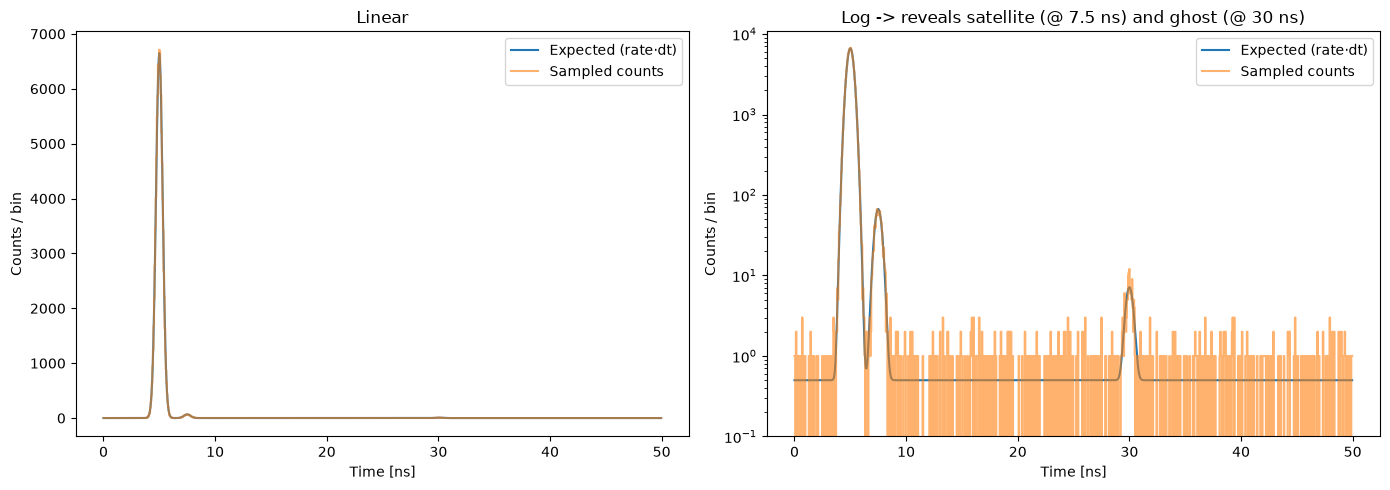

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax in (ax1, ax2):
    ax.plot(t_grid, lam, label='Expected (rate·dt)', lw=1.5)
    ax.plot(t_grid, counts, drawstyle='steps-mid', label='Sampled counts', alpha=0.6)
    ax.set_xlabel('Time [ns]')
    ax.set_ylabel('Counts / bin')
    ax.legend()

ax2.set_yscale('log')
ax2.set_ylim(0.1, None)
ax1.set_title('Linear')
ax2.set_title('Log -> reveals satellite (@ 7.5 ns) and ghost (@ 30 ns)')
plt.tight_layout()

Observations:
- Three peaks in the log plot, at 5, 7.5, and 30 ns.
- The random fluctuations are larger where the counts are larger =  regions with many counts (the peak) show a larger absolute spread, while regions with few counts (the tails) show a smaller absolute spread, even though their relative uncertainty is larger. (Poisson σ = √μ). A bin with μ=6600 scatters by ~81 (~1%); a bin with μ=0.5 scatters by ~0.7 (200%). -> at high counts, the Poisson distribution is approximately Gaussian
- Background level is ~0.5 counts/bin between the peaks, most bins showing 0 or 1.